# Data cleaning

**Missing data**:
- Iterative imputer (+/- indicator)
- KNN imputer (+/- indicator)

**Feature encoding**
- One-hot
- Target

## 1. Notebook setup

### 1.1. Imports

In [1]:
# Standard library
import json
import pickle

# Third party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import balanced_accuracy_score, log_loss
from sklearn.model_selection import StratifiedKFold

# Internal imports
from helper_functions.data_preprocessing import knn_imputer, iterative_imputer, one_hot_encoder, target_encoder, encode_label

### 1.2. Run configuration

In [2]:
SAMPLE       = 0.10  # Fraction of data to use for training
CV_FOLDS     = 5     # Number of cross-validation folds

# Run control flags
RUN_FULL_CONDITION_SWEEP            = True
RUN_ENCODING_SMOOTHING_OPTIMIZATION = True
RUN_IMPUTER_OPTIMIZATION            = True
CREATE_EVAL_DATA                    = True
RUN_PERFORMANCE_ESTIMATION          = True
RUN_HYPERPARAMETER_OPTIMIZATION     = True
CREATE_FINAL_DATA                   = True

# File paths for data
FULL_CONDITION_SWEEP_DATA           = '../data/results/03-encoding-imputation.csv'
ENCODING_SMOOTHING_DATA             = '../data/results/03-target-encoding-smoothing.csv'
ITERATIVE_IMPUTER_OPTIMIZATION_DATA = '../data/results/03-iterative-imputer-optimization.csv'
CROSS_VALIDATION_SCORES             = '../data/results/03-cross-validation-scores.csv'
HYPERPARAMETER_COMBINATIONS         = '../data/results/03-hyperparameter-combinations.pkl'
HYPERPARAMETER_SCORES               = '../data/results/03-hyperparameter-scores.pkl'
WINNING_HYPERPARAMETERS             = '../data/results/03-winning-hyperparameters.pkl'
CV_FOLD_DATASET                     = '../data/tmp/03-preprocessed-cv-folds.pkl'
FINAL_TRAINING_DATA                 = '../data/tmp/03-preprocessed-train-data.csv'
FINAL_TESTING_DATA                  = '../data/tmp/03-preprocessed-test-data.csv'

## 2. Data preparation

### 2.1. Data loading 

In [3]:
# Load raw data
train_df = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/student-health-risk-train.csv')
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

### 2.2. Metadata loading

In [4]:
# Load dataset metadata
with open("../data/schema.json", "r") as f:
    metadata = json.load(f)

# Extract feature lists
features = metadata['features']
categorical_features = metadata['categorical_features']
continuous_features = metadata['continuous_features']
high_cardinality_feature = metadata['high_cardinality_feature']
label = metadata['label']

print(f'Categorical features: {", ".join(categorical_features)}')
print(f'Continuous features: {", ".join(continuous_features)}')
print(f'High cardinality feature: {high_cardinality_feature}')
print(f'Label: {label}')

Categorical features: diet_type, stress_level, sleep_quality, physical_activity_level, smoking_alcohol, gender
Continuous features: sleep_duration, heart_rate, bmi, calorie_expenditure, step_count, exercise_duration, water_intake
High cardinality feature: step_count
Label: health_condition


### 2.3. Data sampling

In [5]:
# Take sample
n = int(len(train_df) * SAMPLE)
train_df = train_df.sample(n=n)

### 2.4. Data cleaning and formatting

In [6]:
# Preserve label column
training_label = train_df['health_condition']

# Remove id and label columns
train_df.drop(['id', 'health_condition'], axis=1, inplace=True)
train_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 69008 entries, 195673 to 65922
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sleep_duration           61358 non-null  float64
 1   heart_rate               68276 non-null  float64
 2   bmi                      67635 non-null  float64
 3   calorie_expenditure      63637 non-null  float64
 4   step_count               67653 non-null  float64
 5   exercise_duration        68302 non-null  float64
 6   water_intake             64672 non-null  float64
 7   diet_type                68306 non-null  object 
 8   stress_level             60650 non-null  object 
 9   sleep_quality            63239 non-null  object 
 10  physical_activity_level  65332 non-null  object 
 11  smoking_alcohol          66165 non-null  object 
 12  gender                   66862 non-null  object 
dtypes: float64(7), object(6)
memory usage: 7.4+ MB


## 3. Experiments

### 3.1. Imputation x encoding strategy

#### 3.1.1. Condition definitions

In [7]:
from configuration.data_preprocessing import conditions

print(f'Total {len(conditions.keys())} conditions')

Total 32 conditions


#### 3.1.2. Condition testing

In [8]:
%%time

if RUN_FULL_CONDITION_SWEEP:

    results = {
        'Condition': [],
        'Cross-validation score': []
    }

    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=315)

    for condition_name, condition_params in conditions.items():
        print(f'Evaluating condition: {condition_name}... ', end='')

        cv_scores = []

        # Fold-level preprocessing prevents train/validation leakage
        for train_idx, validation_idx in cv.split(train_df, training_label):
            x_train = train_df.iloc[train_idx].copy()
            x_validation = train_df.iloc[validation_idx].copy()

            y_train = training_label.iloc[train_idx]
            y_validation = training_label.iloc[validation_idx]

            # Apply the feature encoding on fold training data and transform validation data
            if condition_params['Encoder'] == 'One-hot encoder':
                x_train, x_validation = one_hot_encoder(
                    features=categorical_features,
                    train_df=x_train,
                    test_df=x_validation
                )

            elif condition_params['Encoder'] == 'Target encoder':
                x_train, x_validation = target_encoder(
                    features=categorical_features,
                    train_df=x_train,
                    train_label=y_train,
                    test_df=x_validation,
                    smooth=condition_params['Target smoothing']
                )

            # Apply imputation on fold training data and transform validation data
            if condition_params['Imputer'] == 'KNN imputer':
                x_train, x_validation = knn_imputer(
                    features=continuous_features,
                    train_df=x_train,
                    test_df=x_validation,
                    n_neighbors=condition_params['KNN neighbors'],
                    indicator=condition_params['Missing indicator']
                )

            elif condition_params['Imputer'] == 'Iterative imputer':
                x_train, x_validation = iterative_imputer(
                    features=continuous_features,
                    train_df=x_train,
                    test_df=x_validation,
                    indicator=condition_params['Missing indicator']
                )

            model = HistGradientBoostingClassifier()
            model.fit(x_train, y_train)

            y_pred_proba = model.predict_proba(x_validation)
            score = log_loss(y_validation, y_pred_proba, labels=model.classes_)
            cv_scores.append(score)

        # Collect results
        results['Condition'].extend([condition_name] * CV_FOLDS)
        results['Cross-validation score'].extend(cv_scores)

        print(f'Log loss: {np.median(cv_scores):.4f} +/- {np.std(cv_scores):.4f}')

    results = pd.DataFrame(results)
    results.sort_values(by='Cross-validation score', ascending=True, inplace=True)
    results.reset_index(drop=True, inplace=True)
    results.to_csv(FULL_CONDITION_SWEEP_DATA, index=False)

else:
    results = pd.read_csv(FULL_CONDITION_SWEEP_DATA)

median_scores = results.groupby('Condition')['Cross-validation score'].median().sort_values(ascending=True)
best_condition = median_scores.index[0]
best_score = median_scores.iloc[0]

print(f'Best condition: {best_condition}')
print(f'Median log-loss: {best_score:.4f}')

print()

Evaluating condition: One-hot encoding, KNN imputation (3 neighbors), -indicator... Log loss: 0.1227 +/- 0.0043
Evaluating condition: One-hot encoding, KNN imputation (5 neighbors), -indicator... Log loss: 0.1222 +/- 0.0056
Evaluating condition: One-hot encoding, KNN imputation (7 neighbors), -indicator... Log loss: 0.1211 +/- 0.0047
Evaluating condition: One-hot encoding, KNN imputation (3 neighbors), +indicator... Log loss: 0.0984 +/- 0.0048
Evaluating condition: One-hot encoding, KNN imputation (5 neighbors), +indicator... Log loss: 0.0974 +/- 0.0047
Evaluating condition: One-hot encoding, KNN imputation (7 neighbors), +indicator... Log loss: 0.0980 +/- 0.0049
Evaluating condition: Target encoding (smoothing 0.1), KNN imputation (3 neighbors), -indicator... Log loss: 0.1242 +/- 0.0058
Evaluating condition: Target encoding (smoothing 0.1), KNN imputation (5 neighbors), -indicator... Log loss: 0.1229 +/- 0.0052
Evaluating condition: Target encoding (smoothing 0.1), KNN imputation (7 n

#### 3.1.1. Results

##### 3.1.3.2. Mean score distribution over conditions

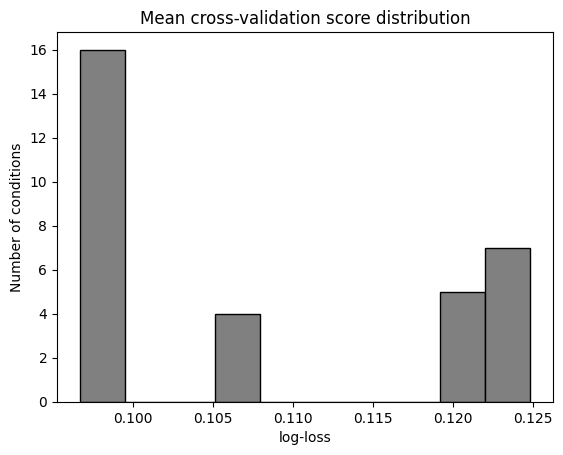

,Cross-validation score
count,32.000000
mean,0.107813
std,0.011788
min,0.096687
25%,0.097381
50%,0.102221
75%,0.120621
max,0.124844


In [9]:
mean_results = pd.DataFrame(results.groupby('Condition').mean())
mean_results.reset_index(drop=False, inplace=True)
mean_results.head()

plt.title('Mean cross-validation score distribution')
plt.hist(mean_results['Cross-validation score'], color='gray', edgecolor='black', bins=10)
plt.xlabel('log-loss')
plt.ylabel('Number of conditions')
plt.show()

mean_results.describe()

##### 3.1.3.2. Mean score by condition

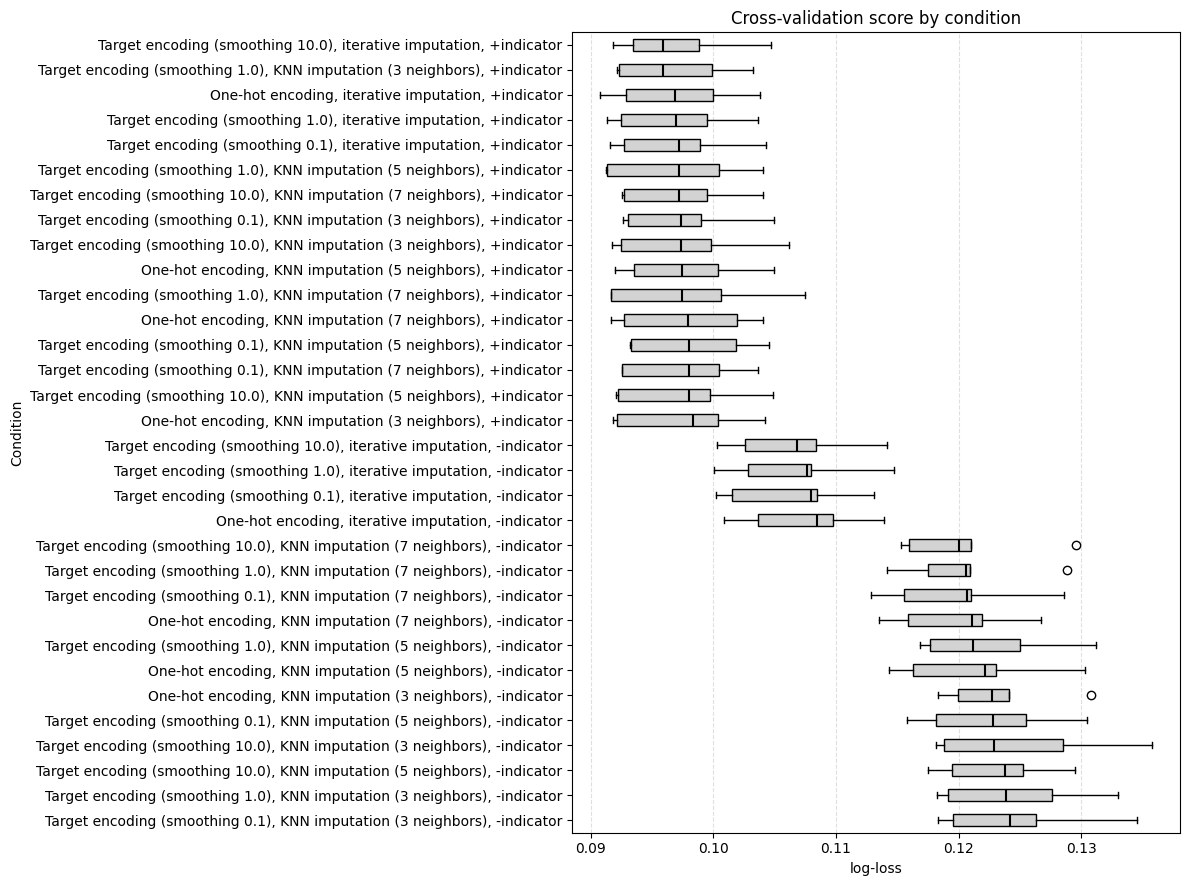

In [10]:
# Order conditions by median score for a readable top-to-bottom plot
condition_order = (
    results.groupby('Condition')['Cross-validation score']
    .median()
    .sort_values(ascending=False)
    .index
)

plot_data = [
    results.loc[results['Condition'] == condition, 'Cross-validation score'].values
    for condition in condition_order
]

fig_height = max(6, len(condition_order) * 0.28)

plt.figure(figsize=(12, fig_height))
plt.boxplot(
    plot_data,
    vert=False,
    tick_labels=condition_order,
    patch_artist=True,
    boxprops={'facecolor': 'lightgray', 'edgecolor': 'black'},
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'color': 'black'},
    capprops={'color': 'black'}
)

plt.title('Cross-validation score by condition')
plt.xlabel('log-loss')
plt.ylabel('Condition')
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


Winner is target encoding with smoothing set to 10 and iterative imputation plus a 'missingness' indicator for continuous features.

### 3.2. Target encoding smoothing optimization

**Fixed choices**:
- Categorical encoding: target encoder, with category for missing values
- Missing value imputation: Iterative imputer
- Missing indicator added for continuous features

**Sweep**:
- TargetEncoder smooth in [1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 'auto']

#### 3.2.1. Optimization run

In [11]:
%%time

if RUN_ENCODING_SMOOTHING_OPTIMIZATION:

    smoothing_values = [1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 'auto']

    target_encoding_results = {
        'Smoothing': [],
        'Cross-validation score': []
    }

    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=315)

    for smooth_value in smoothing_values:
        print(f'Evaluating smoothing: {smooth_value}... ', end='')

        cv_scores = []

        for train_idx, validation_idx in cv.split(train_df, training_label):
            x_train = train_df.iloc[train_idx].copy()
            x_validation = train_df.iloc[validation_idx].copy()

            y_train = training_label.iloc[train_idx]
            y_validation = training_label.iloc[validation_idx]

            x_train, x_validation = target_encoder(
                features=categorical_features,
                train_df=x_train,
                train_label=y_train,
                test_df=x_validation,
                smooth=smooth_value
            )

            x_train, x_validation = iterative_imputer(
                features=continuous_features,
                train_df=x_train,
                test_df=x_validation,
                indicator=True
            )

            model = HistGradientBoostingClassifier()
            model.fit(x_train, y_train)

            y_pred_proba = model.predict_proba(x_validation)
            score = log_loss(y_validation, y_pred_proba, labels=model.classes_)
            cv_scores.append(score)

        target_encoding_results['Smoothing'].extend([smooth_value] * CV_FOLDS)
        target_encoding_results['Cross-validation score'].extend(cv_scores)

        print(f'Log loss: {np.median(cv_scores):.4f} +/- {np.std(cv_scores):.4f}')

    target_encoding_results = pd.DataFrame(target_encoding_results)
    target_encoding_results.sort_values(by='Cross-validation score', ascending=True, inplace=True)
    target_encoding_results.reset_index(drop=True, inplace=True)
    target_encoding_results.to_csv(ENCODING_SMOOTHING_DATA, index=False)

else:
    target_encoding_results = pd.read_csv(ENCODING_SMOOTHING_DATA)

median_smoothing_scores = target_encoding_results.groupby('Smoothing')['Cross-validation score'].median().sort_values(ascending=True)
best_target_smoothing = median_smoothing_scores.index[0]
best_target_smoothing_score = median_smoothing_scores.iloc[0]

print(f'Best target smoothing: {best_target_smoothing}')
print(f'Median log-loss: {best_target_smoothing_score:.4f}')
print()


Evaluating smoothing: 1.0... Log loss: 0.0976 +/- 0.0038
Evaluating smoothing: 2.0... Log loss: 0.0972 +/- 0.0042
Evaluating smoothing: 4.0... Log loss: 0.0965 +/- 0.0053
Evaluating smoothing: 8.0... Log loss: 0.0967 +/- 0.0043
Evaluating smoothing: 16.0... Log loss: 0.0980 +/- 0.0048
Evaluating smoothing: 32.0... Log loss: 0.0961 +/- 0.0052
Evaluating smoothing: 64.0... Log loss: 0.0971 +/- 0.0048
Evaluating smoothing: auto... Log loss: 0.0970 +/- 0.0041
Best target smoothing: 32.0
Median log-loss: 0.0961

CPU times: user 10h 35min 20s, sys: 2min 9s, total: 10h 37min 29s
Wall time: 44min 18s


#### 3.2.2. Results

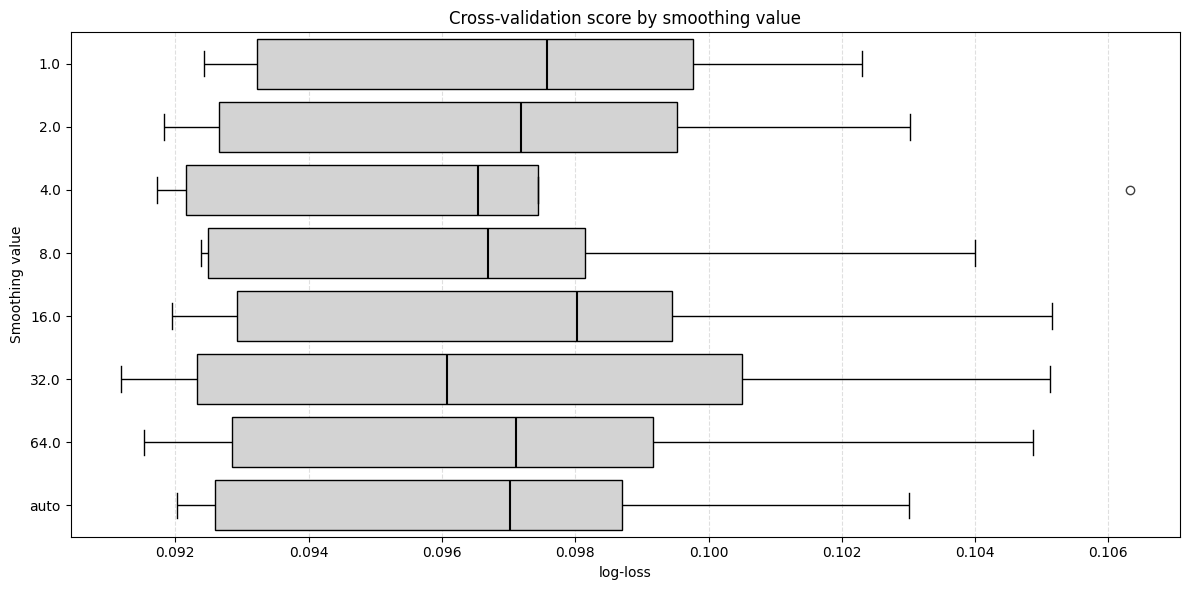

In [12]:
# Force display order: numeric smoothing values ascending, then 'auto' last
numeric_smoothing = sorted(
    float(value)
    for value in target_encoding_results['Smoothing'].unique()
    if str(value).lower() != 'auto'
)

has_auto = any(str(value).lower() == 'auto' for value in target_encoding_results['Smoothing'])

smoothing_order = [str(value) for value in numeric_smoothing]

if has_auto:
    smoothing_order.append('auto')

plot_df = target_encoding_results.copy()
plot_df['Smoothing'] = plot_df['Smoothing'].astype(str)

fig_height = max(6, len(smoothing_order) * 0.5)

plt.figure(figsize=(12, fig_height))
sns.boxplot(
    x='Cross-validation score',
    y='Smoothing',
    data=plot_df,
    order=smoothing_order,
    orient='h',
    boxprops={'facecolor': 'lightgray', 'edgecolor': 'black'},
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'color': 'black'},
    capprops={'color': 'black'}
)

plt.title('Cross-validation score by smoothing value')
plt.xlabel('log-loss')
plt.ylabel('Smoothing value')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 3.3. Iterative imputer optimization

**Fixed choices**:
- Categorical encoding: target encoder, with category for missing values
- Missing value imputation: Iterative imputer
- Missing indicator added for continuous features
- Target encoding with smoothing value 32

**Sweep**:
- max_iter in [5, 10, 20]
- initial_strategy in ['mean', 'median']
- imputation_order in ['ascending', 'roman', 'random']

#### 3.3.1. Optimization run

In [13]:
%%time

if RUN_IMPUTER_OPTIMIZATION:

    iterative_conditions = []

    for max_iter in [5, 10, 20]:
        for initial_strategy in ['mean', 'median']:
            for imputation_order in ['ascending', 'roman', 'random']:
                iterative_conditions.append({
                    'max_iter': max_iter,
                    'initial_strategy': initial_strategy,
                    'imputation_order': imputation_order
                })

    iterative_results = {
        'Condition': [],
        'Cross-validation score': []
    }

    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=315)

    for condition in iterative_conditions:
        condition_name = (
            f"Target encoding (smoothing {best_target_smoothing}), "
            f"iterative imputation (max_iter={condition['max_iter']}, "
            f"initial={condition['initial_strategy']}, "
            f"order={condition['imputation_order']}), +indicator"
        )

        print(f'Evaluating condition: {condition_name}... ', end='')
        cv_scores = []

        for train_idx, validation_idx in cv.split(train_df, training_label):
            x_train = train_df.iloc[train_idx].copy()
            x_validation = train_df.iloc[validation_idx].copy()

            y_train = training_label.iloc[train_idx]
            y_validation = training_label.iloc[validation_idx]

            x_train, x_validation = target_encoder(
                features=categorical_features,
                train_df=x_train,
                train_label=y_train,
                test_df=x_validation,
                smooth=best_target_smoothing
            )

            x_train, x_validation = iterative_imputer(
                features=continuous_features,
                train_df=x_train,
                test_df=x_validation,
                indicator=True,
                max_iter=condition['max_iter'],
                initial_strategy=condition['initial_strategy'],
                imputation_order=condition['imputation_order'],
                random_state=315
            )

            model = HistGradientBoostingClassifier()
            model.fit(x_train, y_train)

            y_pred_proba = model.predict_proba(x_validation)
            score = log_loss(y_validation, y_pred_proba, labels=model.classes_)
            cv_scores.append(score)

        iterative_results['Condition'].extend([condition_name] * CV_FOLDS)
        iterative_results['Cross-validation score'].extend(cv_scores)

        print(f'Log loss: {np.median(cv_scores):.4f} +/- {np.std(cv_scores):.4f}')

    iterative_results = pd.DataFrame(iterative_results)
    iterative_results.sort_values(by='Cross-validation score', ascending=True, inplace=True)
    iterative_results.reset_index(drop=True, inplace=True)
    iterative_results.to_csv(ITERATIVE_IMPUTER_OPTIMIZATION_DATA, index=False)

else:
    iterative_results = pd.read_csv(ITERATIVE_IMPUTER_OPTIMIZATION_DATA)
    print('Loaded iterative imputer optimization results from disk')

median_iterative_scores = iterative_results.groupby('Condition')['Cross-validation score'].median().sort_values(ascending=True)
best_condition = median_iterative_scores.index[0]
best_score = median_iterative_scores.iloc[0]

print(f'Best condition: {best_condition}')
print(f'Median log-loss: {best_score:.4f}')
print()


Evaluating condition: Target encoding (smoothing 32.0), iterative imputation (max_iter=5, initial=mean, order=ascending), +indicator... Log loss: 0.0970 +/- 0.0046
Evaluating condition: Target encoding (smoothing 32.0), iterative imputation (max_iter=5, initial=mean, order=roman), +indicator... Log loss: 0.0980 +/- 0.0043
Evaluating condition: Target encoding (smoothing 32.0), iterative imputation (max_iter=5, initial=mean, order=random), +indicator... Log loss: 0.0967 +/- 0.0046
Evaluating condition: Target encoding (smoothing 32.0), iterative imputation (max_iter=5, initial=median, order=ascending), +indicator... Log loss: 0.0959 +/- 0.0045
Evaluating condition: Target encoding (smoothing 32.0), iterative imputation (max_iter=5, initial=median, order=roman), +indicator... Log loss: 0.0975 +/- 0.0050
Evaluating condition: Target encoding (smoothing 32.0), iterative imputation (max_iter=5, initial=median, order=random), +indicator... Log loss: 0.0965 +/- 0.0044
Evaluating condition: Ta

#### 3.3.2. Results

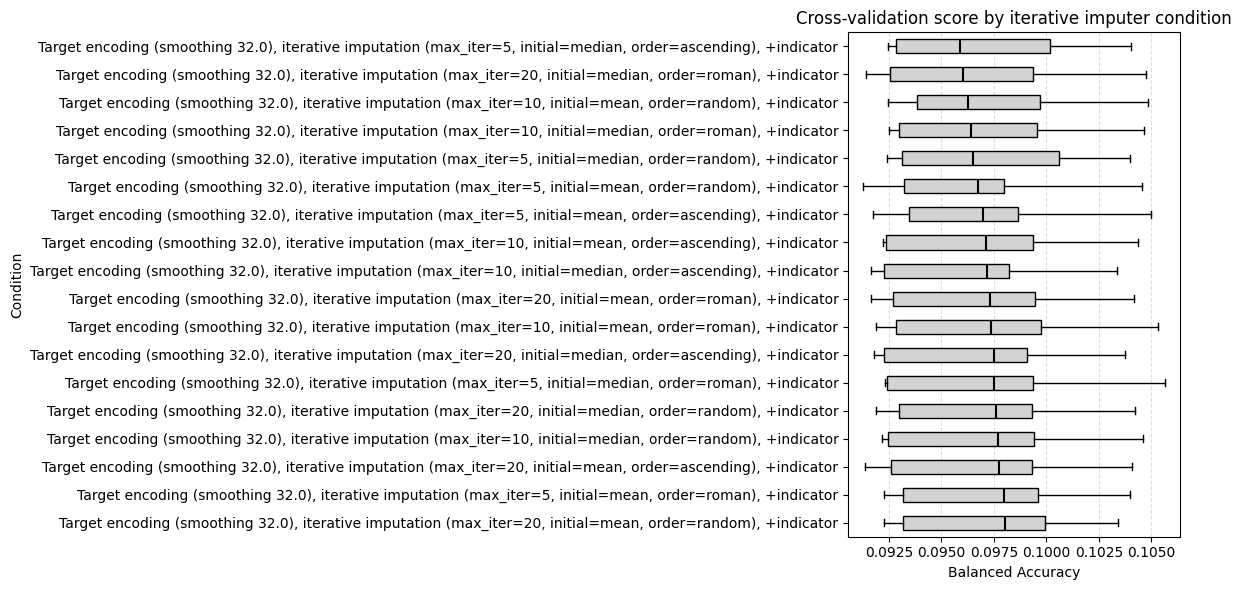

In [14]:
# Order conditions by mean score for a readable top-to-bottom plot
condition_order = (
    iterative_results.groupby('Condition')['Cross-validation score']
    .median()
    .sort_values(ascending=False)
    .index
)

plot_data = [
    iterative_results.loc[iterative_results['Condition'] == condition, 'Cross-validation score'].values
    for condition in condition_order
]

fig_height = max(6, len(condition_order) * 0.28)

plt.figure(figsize=(12, fig_height))
plt.boxplot(
    plot_data,
    vert=False,
    tick_labels=condition_order,
    patch_artist=True,
    boxprops={'facecolor': 'lightgray', 'edgecolor': 'black'},
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'color': 'black'},
    capprops={'color': 'black'}
)

plt.title('Cross-validation score by iterative imputer condition')
plt.xlabel('Balanced Accuracy')
plt.ylabel('Condition')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 4. Conclusion

The final optimized data preprocessing pipeline is:

1. Iterative imputation
    - `max_iter`: 5
    - `initial`: mean
    - `order`: ascending

2. Target encoding
    - `smoothing`: 32.0

A missing indicator is included for all features. For categorical data, the encoder handles `NaN` as and additional category. For each imputed continuous features, a binary indicator feature is added.

## 5. Performance estimation

This is made a bit more complex by the choice of encoding techniques. If we run cross-validation on a dataset that has been encoded in one shot with target encoder, we will get data leakage between the folds. Instead, we need to generate cross validation folds and pre-process them individual.

In [15]:
# Number of folds to use for cross-validation during final model evaluation and hyperparameter tuning
CV_FOLDS = 10

### 5.1. Load and prep raw data

In [16]:
# Load clean data
train_df = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/student-health-risk-train.csv')

# Preserve label column
training_label = train_df['health_condition']

# Encode labels
training_label, label_encoder = encode_label(training_label)

# Remove id and label columns
train_df.drop(['id', 'health_condition'], axis=1, inplace=True)
train_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   sleep_duration           614089 non-null  float64
 1   heart_rate               682255 non-null  float64
 2   bmi                      676190 non-null  float64
 3   calorie_expenditure      637235 non-null  float64
 4   step_count               676172 non-null  float64
 5   exercise_duration        683187 non-null  float64
 6   water_intake             646611 non-null  float64
 7   diet_type                683187 non-null  object 
 8   stress_level             607277 non-null  object 
 9   sleep_quality            631757 non-null  object 
 10  physical_activity_level  653467 non-null  object 
 11  smoking_alcohol          661506 non-null  object 
 12  gender                   668715 non-null  object 
dtypes: float64(7), object(6)
memory usage: 68.4+ MB


### 5.2. Create cross-validation folds

In [17]:
if CREATE_EVAL_DATA:

    # Create cross-validation splitter
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=315)

    # Empty list to hold folds
    cv_folds = []

    # Loop on splits
    for train_idx, validation_idx in cv.split(train_df, training_label):

        # Get training and validation features
        x_train = train_df.iloc[train_idx].copy()
        x_validation = train_df.iloc[validation_idx].copy()

        # Get training and validation labels
        y_train = training_label[train_idx]
        y_validation = training_label[validation_idx]

        # Collect fold data
        cv_folds.append({
            'x_train': x_train,
            'x_validation': x_validation,
            'y_train': y_train,
            'y_validation': y_validation
        })

### 5.3. Preprocess each fold

In [18]:
if CREATE_EVAL_DATA:

    # Loop on folds
    for fold in cv_folds:

        # Target encoding with smoothing 1.0
        fold['x_train'], fold['x_validation'] = target_encoder(
            features=categorical_features,
            train_df=fold['x_train'],
            train_label=fold['y_train'],
            test_df=fold['x_validation'],
            smooth=1.0
        )

        # Iterative imputation with max_iter=20, initial_strategy='mean',
        # imputation_order='ascending', and indicator=True
        fold['x_train'], fold['x_validation'] = iterative_imputer(
            features=continuous_features,
            train_df=fold['x_train'],
            test_df=fold['x_validation'],
            indicator=True,
            max_iter=20,
            initial_strategy='mean',
            imputation_order='ascending'
        )

    with open(CV_FOLD_DATASET, 'wb') as f:
        pd.to_pickle(cv_folds, f)

else:
    with open(CV_FOLD_DATASET, 'rb') as f:
        cv_folds = pd.read_pickle(f)

### 5.4. Naive gradient boosting classifier

In [19]:
%%time

if RUN_PERFORMANCE_ESTIMATION:

    # Train and evaluate a Gradient Boosting Classifier on each fold
    fold_scores = []

    for i, fold in enumerate(cv_folds):
        print(f'Fold {i + 1} of {CV_FOLDS}...', end='\r')
        model = HistGradientBoostingClassifier(random_state=315)
        model.fit(fold['x_train'], fold['y_train'])

        y_pred = model.predict(fold['x_validation'])
        score = balanced_accuracy_score(fold['y_validation'], y_pred)
        fold_scores.append(score)

    with open(CROSS_VALIDATION_SCORES, 'wb') as f:
        pickle.dump(fold_scores, f)

    print()

else:

    with open(CROSS_VALIDATION_SCORES, 'rb') as f:
        fold_scores = pickle.load(f)

ci_lower, ci_upper = np.percentile(fold_scores, [2.5, 97.5])

print(f"Mean balanced accuracy score: {sum(fold_scores) / len(fold_scores):.4f}")
print(f"Median balanced accuracy score: {np.median(fold_scores):.4f}")
print(f"95% confidence interval: [{ci_lower:.4f}, {ci_upper:.4f}]")

print()

Fold 10 of 10...
Mean balanced accuracy score: 0.8728
Median balanced accuracy score: 0.8726
95% confidence interval: [0.8696, 0.8769]

CPU times: user 50min 42s, sys: 11.4 s, total: 50min 53s
Wall time: 3min 32s


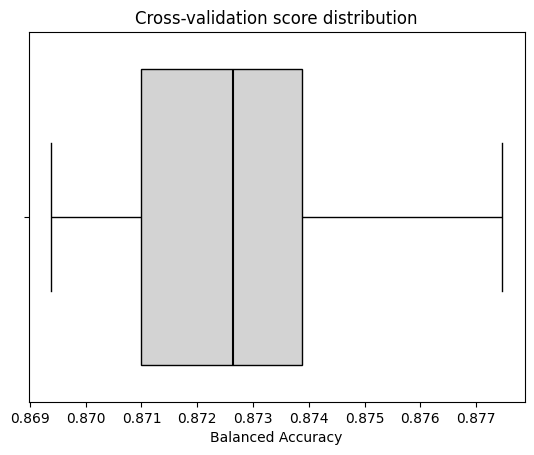

In [20]:
plt.title('Cross-validation score distribution')
sns.boxplot(
    x=fold_scores,
    color='lightgray',
    boxprops={'facecolor': 'lightgray', 'edgecolor': 'black'},
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'color': 'black'},
    capprops={'color': 'black'}
)
plt.xlabel('Balanced Accuracy')
plt.show()

## 6. Hyperparameter tuning

We will use the same independently preprocessed folds for the model hyperparameter optimization.

### 6.1. Hyperparameter search space

In [21]:
if RUN_HYPERPARAMETER_OPTIMIZATION:

    # Parameter distributions
    params = {
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_iter': [100, 200, 300, 400],
        'max_features': [0.6, 0.8, 1.0]
    }

    print(f'Total hyperparameter combinations: {np.prod([len(v) for v in params.values()])}')

    parameter_combinations = [
        {key: value for key, value in zip(params.keys(), combination)}
        for combination in np.array(np.meshgrid(*params.values())).T.reshape(-1, len(params))
    ]

    parameter_combinations = [
        {k: (int(v) if k in ['max_depth', 'max_iter'] else v) for k, v in combination.items()}
        for combination in parameter_combinations
    ]

    with open(HYPERPARAMETER_COMBINATIONS, 'wb') as f:
        pickle.dump(parameter_combinations, f)

else:
    
    with open(HYPERPARAMETER_COMBINATIONS, 'rb') as f:
        parameter_combinations = pickle.load(f)

print('Example hyperparameter combinations:')
print(parameter_combinations[0])  # Display first 5 combinations

Total hyperparameter combinations: 192
Example hyperparameter combinations:
{'max_depth': 3, 'learning_rate': np.float64(0.01), 'max_iter': 100, 'max_features': np.float64(0.6)}


### 6.2. Optimization run

In [22]:
%%time

if RUN_HYPERPARAMETER_OPTIMIZATION:

    scores = {
        'parameter_index': [],
        'score': []
    }

    for idx, param_combination in enumerate(parameter_combinations):
        fold_scores = []

        for fold in cv_folds:
            model = HistGradientBoostingClassifier(**param_combination, random_state=315)
            model.fit(fold['x_train'], fold['y_train'])

            y_pred_proba = model.predict_proba(fold['x_validation'])
            score = log_loss(fold['y_validation'], y_pred_proba, labels=model.classes_)
            fold_scores.append(score)

        scores['parameter_index'].extend([idx] * len(fold_scores))
        scores['score'].extend(fold_scores)

        median_score = np.median(fold_scores)
        print(f'Combination {idx + 1} of {len(parameter_combinations)}: median log loss = {median_score:.4f}', end='\r')

    with open(HYPERPARAMETER_SCORES, 'wb') as f:
        pickle.dump(scores, f)

else:
    
    with open(HYPERPARAMETER_SCORES, 'rb') as f:
        scores = pickle.load(f)
    
print('\n')


Combination 192 of 192: median log loss = 0.0944

CPU times: user 9d 10h 38min 9s, sys: 54min 1s, total: 9d 11h 32min 10s
Wall time: 15h 33min 26s


### 6.3. Results

In [23]:
scores_df = pd.DataFrame(scores)
median_scores_df = scores_df.groupby('parameter_index')['score'].median().reset_index()
median_scores_df.rename(columns={'score': 'median_score'}, inplace=True)
median_scores_df.reset_index(inplace=True)
median_scores_df['95% CI lower'] = scores_df.groupby('parameter_index')['score'].apply(lambda x: np.percentile(x, 2.5)).values
median_scores_df['95% CI upper'] = scores_df.groupby('parameter_index')['score'].apply(lambda x: np.percentile(x, 97.5)).values
median_scores_df.sort_values(by='median_score', ascending=True, inplace=True)

print(f'Winner: {median_scores_df.iloc[0].to_dict()}')

winning_params = parameter_combinations[int(median_scores_df.iloc[0]['index'])]

with open(WINNING_HYPERPARAMETERS, 'wb') as f:
    pickle.dump(winning_params, f)


Winner: {'index': 89.0, 'parameter_index': 89.0, 'median_score': 0.08943353084777139, '95% CI lower': 0.08828399734602616, '95% CI upper': 0.09202213296787874}


Text(0, 0.5, 'Median log loss')

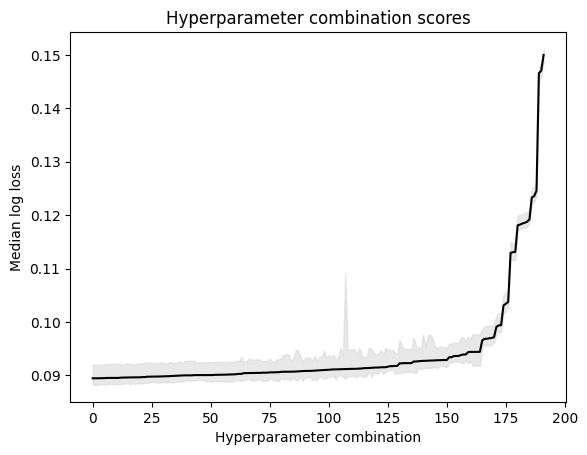

In [24]:
plt.title('Hyperparameter combination scores')
plt.plot(list(range(len(median_scores_df))), median_scores_df['median_score'], color='black')
plt.fill_between(
    list(range(len(median_scores_df))),
    median_scores_df['95% CI lower'],
    median_scores_df['95% CI upper'],
    color='lightgray',
    alpha=0.5
)
plt.xlabel('Hyperparameter combination')
plt.ylabel('Median log loss')


## 6. Final dataset

Preprocess the whole dataset in one go to train the optimized mode for final submission.

In [25]:
if CREATE_FINAL_DATA:
    
    # Load clean copy of raw training data
    train_df = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/student-health-risk-train.csv')
    test_df = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/student-health-risk-test.csv')

    # Preserve testing id column
    test_ids = test_df['id']

    # Preserve label column
    training_label = train_df['health_condition']

    # Encode the label
    training_label, _ = encode_label(training_label)

    # Remove id and label columns
    train_df.drop(['id', 'health_condition'], axis=1, inplace=True)
    test_df.drop('id', axis=1, inplace=True)

    # Target encoding with smoothing 1.0
    train_df, test_df = target_encoder(
        features=categorical_features,
        train_df=train_df,
        train_label=training_label,
        test_df=test_df,
        smooth=1.0
    )

    # Iterative imputation with max_iter=20, initial_strategy='mean',
    # imputation_order='ascending', and indicator=True
    train_df, test_df = iterative_imputer(
        features=continuous_features,
        train_df=train_df,
        test_df=test_df,
        indicator=True,
        max_iter=20,
        initial_strategy='mean',
        imputation_order='ascending'
    )

    # Add the labels back to the preprocessed training data
    train_df['health_condition'] = training_label

    # Add the ids back to the preprocessed testing data
    test_df['id'] = test_ids

    # Save
    train_df.to_csv(FINAL_TRAINING_DATA, index=False)
    test_df.to_csv(FINAL_TESTING_DATA, index=False)

else:
    
    train_df = pd.read_csv(FINAL_TRAINING_DATA)
    test_df = pd.read_csv(FINAL_TESTING_DATA)

## 7. Submission

In [26]:
model = HistGradientBoostingClassifier(**winning_params, random_state=315)
model.fit(train_df.drop('health_condition', axis=1), train_df['health_condition'])

y_pred = model.predict(test_df.drop('id', axis=1))

submission_df = pd.DataFrame({
    'id': test_df['id'],
    'health_condition': label_encoder.inverse_transform(y_pred)
})

submission_df.to_csv('../data/submission.csv', index=False)